In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
from astropy.io import fits
from astropy.table import Table
import json
import sys

In [2]:
sys.path.append(str(Path().resolve() / 'py_modules')) 

import list_maps_plots
from spectral_lines import LINES, print_available_lines

In [3]:
# Data from observations
bins        = 0

region     = 'NGC 2070'
name_reg   = '30 Doradus'
reg_id     = '30Dor'
inst       = 'LVM'
inst_id    = 'LVM'
type_obj   = 'H II region'

pix        = 0   # Instrument resolution [arcsec/pix]
dist       = 50000 # Distance [parsecs]
s0_        = 0.9    # proposed seeing

pc         = dist*(2*np.pi) / (360 * 60 * 60)
s0         = (s0_*pc)

In [4]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS

c0 = SkyCoord.from_name("Tarantula")
c0

<SkyCoord (ICRS): (ra, dec) in deg
    (84.675, -69.1)>

In [5]:
fov_deg = 1.0  # Total field of view in degrees (width and height)
pix_scale = 1 / 3600
npix = int(fov_deg / pix_scale)

# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]
wcs.wcs.crpix = [npix, npix]  # center of your "image"
wcs.wcs.cdelt = [-pix_scale, pix_scale]  # field size / pixel count

In [6]:
ra0  = c0.ra.deg
dec0 = c0.dec.deg
#ra0 = _line["RAdeg"].median()
#dec0 = _line["DEdeg"].median()
print(ra0, dec0)

84.675 -69.1


#  Data Ha

In [7]:
cfg = LINES["Halpha"]

plot_label_line      = cfg.plot_label
rest_wavelength = cfg.rest_wavelength
wavelength_id    = cfg.wavelength_id
element         = cfg.element
ion             = cfg.ion
transition_id   = cfg.transition_id

In [8]:
print(plot_label_line)
print(rest_wavelength)
print(wavelength_id)
print(element)
print(ion)
print(transition_id)

H$\alpha$
6562.8
6563
H
H_I
H_I-6563


In [9]:
#line        = r'H$\alpha$'
#lambda_rest = 6562.8
#line_id     = 'H'
#line_id2   = "6563"

In [10]:


#Since we are working with scatter adata there is no binning that can be applied
name_file    =  inst_id + '-' + reg_id + '-' + str(wavelength_id)
name_id      =  inst_id + '-' + reg_id + '-' + element + "-X"
print(name_file)
print(name_id)


LVM-30Dor-6563
LVM-30Dor-H-X


In [11]:
_data = json.load(open('observations/'+ name_file + '-l.json'))
_line = pd.DataFrame(_data['data'])
_line.columns = ['RAdeg', 'DEdeg', 'V_mean','log_F','sigma']
#_line = _line[0:3500]

In [12]:
centro = SkyCoord(ra=ra0*u.deg, dec=dec0*u.deg, frame='icrs')

coords = SkyCoord(
    ra=_line["RAdeg"].values * u.deg,
    dec=_line["DEdeg"].values * u.deg,
    frame='icrs'
)


In [13]:


radio = 3305 * u.arcsec   
sep = coords.separation(centro)

line_rad = _line[sep <= radio]


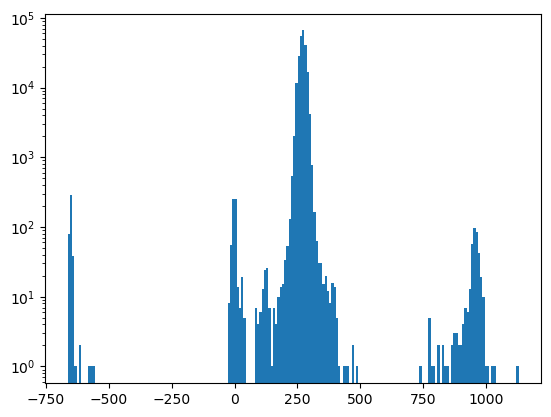

In [14]:
fig, ax = plt.subplots()
plt.hist(line_rad["V_mean"] , bins=200)
ax.set_yscale("log")

In [15]:
mask = (line_rad["V_mean"] > 220) & (line_rad["V_mean"]<330) & (line_rad["log_F"] > 100)  & (line_rad["sigma"] < 1.5) 
line_mask = line_rad[mask]

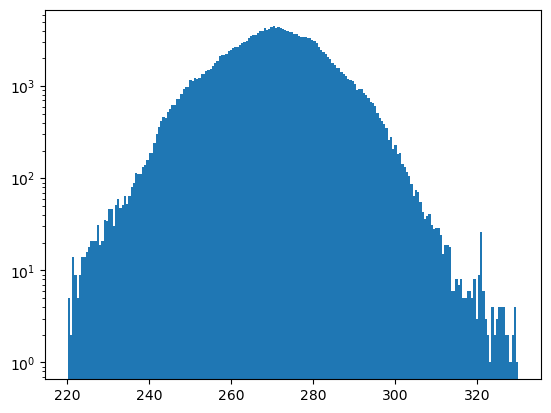

In [16]:
fig, ax = plt.subplots()
plt.hist(line_rad["V_mean"][mask] , bins=200)
ax.set_yscale("log")

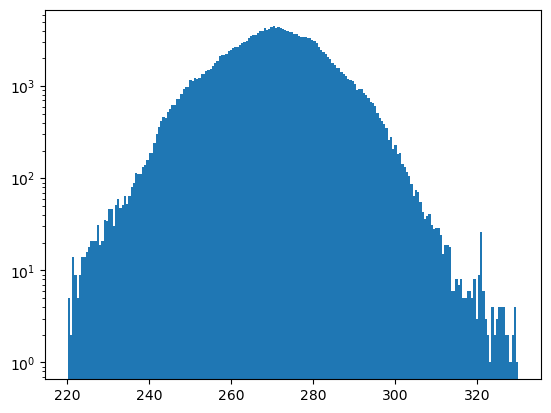

In [17]:
fig, ax = plt.subplots()
plt.hist(line_mask["V_mean"] , bins=200)
ax.set_yscale("log")

Plot flux and radial velocity

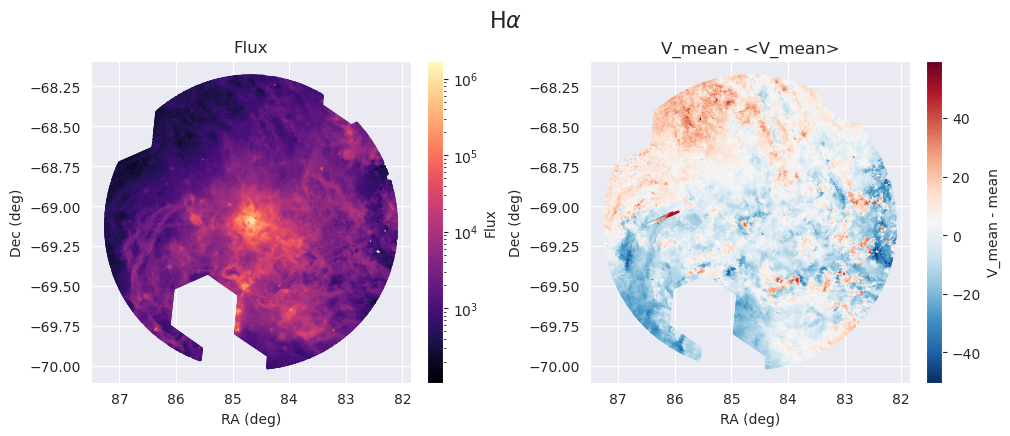

In [18]:
fig, ax = list_maps_plots.plot_panels_log_title(line_mask,
                                                s=1.0,
                                                figsize=(10, 4.25),
                                                titles=("Flux", "V_mean - <V_mean>"),
                                                figure_title=plot_label_line)
plt.show()
#plt.savefig('Imgs/' + name_file + '.jpg', bbox_inches='tight')

Plot flux and radial velocity in WCS

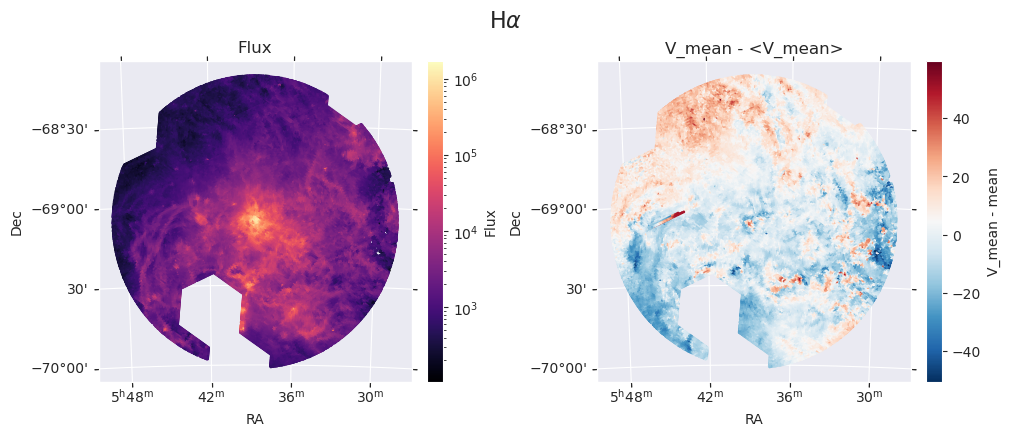

In [19]:
fig, ax = list_maps_plots.plot_panels_wcs(line_mask,
                                          wcs,
                                          s=1.0,
                                          figsize=(10, 4.25),
                                          invert_ra=False, 
                                          titles=("Flux", "V_mean - <V_mean>"),
                                          figure_title=plot_label_line)
plt.show()

#plt.savefig('Imgs/' + name_file + '.jpg', bbox_inches='tight')

In [20]:
df_Ha = line_mask.copy()

In [21]:
df_Ha.describe()

,RAdeg,DEdeg,V_mean,log_F,sigma
count,222020.000000,222020.000000,222020.000000,2.220200e+05,222020.000000
mean,84.743434,-69.080949,270.401268,9.276494e+03,0.841440
std,1.275231,0.427281,12.448334,3.407694e+04,0.129093
min,82.101852,-70.012179,220.023700,1.059342e+02,0.237300
25%,83.781267,-69.404202,262.501525,1.006186e+03,0.752300
50%,84.708755,-69.094773,270.608900,2.636627e+03,0.811500
75%,85.798398,-68.761121,278.533000,6.775874e+03,0.893100
max,87.248872,-68.182110,329.997900,1.710726e+06,1.499700


## Rotation substraction

# Data [OIII]

In [22]:
cfg = LINES["OIII_5007"]

plot_label_line      = cfg.plot_label
rest_wavelength = cfg.rest_wavelength
wavelength_id    = cfg.wavelength_id
element         = cfg.element
ion             = cfg.ion
transition_id   = cfg.transition_id

In [23]:
#Since we are working with scatter adata there is no binning that can be applied
name_file    =  inst_id + '-' + reg_id + '-' + str(wavelength_id)
name_id      =  inst_id + '-' + reg_id + '-' + element + "-X"
print(name_file)
print(name_id)


LVM-30Dor-5007
LVM-30Dor-O-X


In [24]:
_data = json.load(open('observations/'+ name_file + '-l.json'))
_line = pd.DataFrame(_data['data'])
_line.columns = ['RAdeg', 'DEdeg', 'V_mean','log_F','sigma']
#_line = _line[0:3500]

In [25]:
radio = 3305 * u.arcsec   
sep = coords.separation(centro)

line_rad_O = _line[sep <= radio]

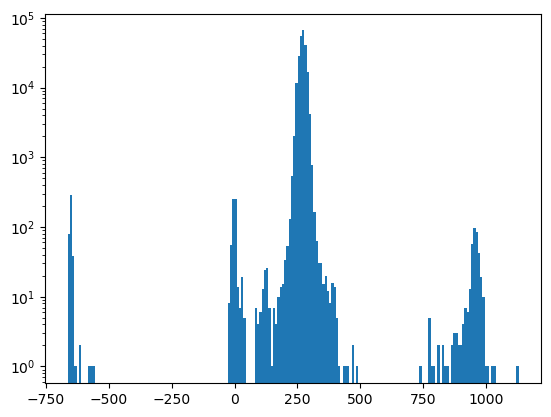

In [26]:
fig, ax = plt.subplots()
plt.hist(line_rad["V_mean"] , bins=200)
ax.set_yscale("log")

In [27]:
mask_O = (line_rad_O["V_mean"] > 220) & \
         (line_rad_O["V_mean"]<330) & \
         (line_rad_O["log_F"] > 100)  & (line_rad_O["sigma"] < 1.5) 
line_mask_O = line_rad_O[mask_O].copy()

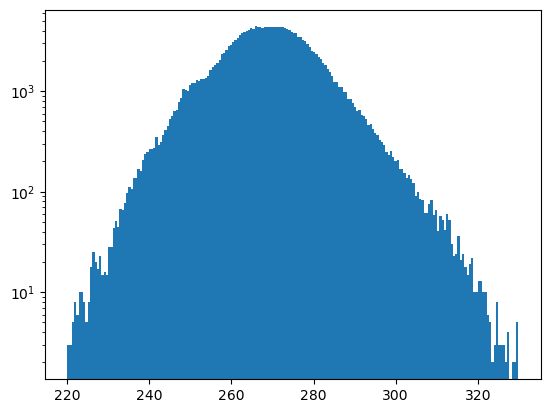

In [28]:
fig, ax = plt.subplots()
plt.hist(line_rad_O["V_mean"][mask_O] , bins=200)
ax.set_yscale("log")

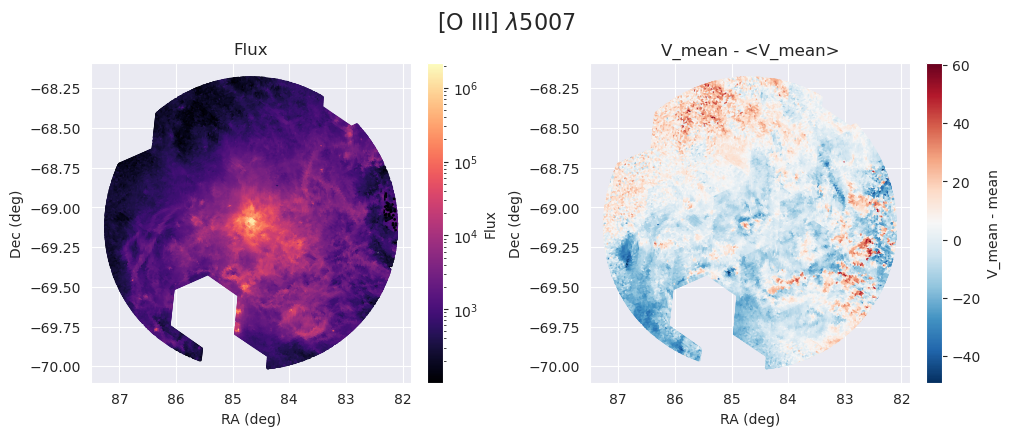

In [29]:
fig, ax = list_maps_plots.plot_panels_log_title(line_mask_O,
                                                s=1.0,
                                                figsize=(10, 4.25),
                                                titles=("Flux", "V_mean - <V_mean>"),
                                                figure_title=plot_label_line)
plt.show()
#plt.savefig('Imgs/' + name_file + '.jpg', bbox_inches='tight')

In [30]:
df_OIII = line_mask_O.copy()

# [N II]

In [31]:
cfg = LINES["NII_6583"]

plot_label_line      = cfg.plot_label
rest_wavelength = cfg.rest_wavelength
wavelength_id    = cfg.wavelength_id
element         = cfg.element
ion             = cfg.ion
transition_id   = cfg.transition_id

In [32]:
print(plot_label_line)
print(rest_wavelength)
print(wavelength_id)
print(element)
print(ion)
print(transition_id)

[N II]$\ \lambda$6584
6583.45
6583
N
N_II
N_II-6583


In [33]:
#Since we are working with scatter adata there is no binning that can be applied
name_file    =  inst_id + '-' + reg_id + '-' + str(wavelength_id)
name_id      =  inst_id + '-' + reg_id + '-' + element + "-X"
print(name_file)
print(name_id)

LVM-30Dor-6583
LVM-30Dor-N-X


In [34]:
_data = json.load(open('observations/'+ name_file + '-l.json'))
_line_N = pd.DataFrame(_data['data'])
_line_N.columns = ['RAdeg', 'DEdeg', 'V_mean','log_F','sigma']

In [35]:
radio = 3305 * u.arcsec   
sep = coords.separation(centro)

line_rad_N = _line_N[sep <= radio].copy()

In [36]:
mask_N = (line_rad_N["V_mean"] > 220) & \
         (line_rad_N["V_mean"]<330)   & \
         (line_rad_N["log_F"] > 100)  & (line_rad_N["sigma"] < 1.5) 

line_mask_N = line_rad_N[mask_N].copy()

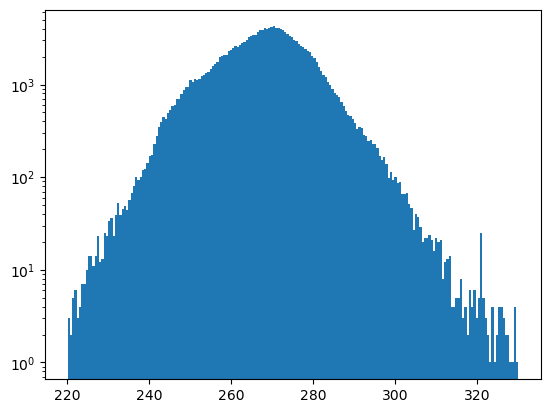

In [37]:
fig, ax = plt.subplots()
plt.hist(line_rad_N["V_mean"][mask_N] , bins=200)
ax.set_yscale("log")

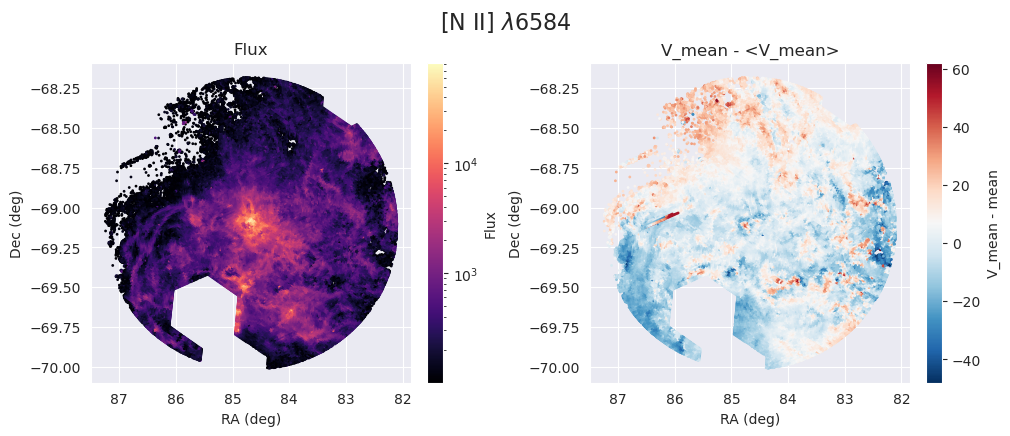

In [38]:
fig, ax = list_maps_plots.plot_panels_log_title(line_mask_N,
                                                s=1.0,
                                                figsize=(10, 4.25),
                                                titles=("Flux", "V_mean - <V_mean>"),
                                                figure_title=plot_label_line)
plt.show()
#plt.savefig('Imgs/' + name_file + '.jpg', bbox_inches='tight')

In [39]:
df_NII = line_mask_N.copy()

# Line Comparison

In [40]:
line_rad.describe()

,RAdeg,DEdeg,V_mean,log_F,sigma
count,226758.000000,226758.000000,226758.000000,2.267580e+05,226758.000000
mean,84.739355,-69.079535,269.215663,9.139823e+03,0.854972
std,1.293269,0.426873,51.541669,3.386645e+04,0.178388
min,82.101852,-70.012179,-664.132500,-3.867703e+02,0.180000
25%,83.762614,-69.401805,262.389625,9.716659e+02,0.752700
50%,84.710111,-69.093216,270.647800,2.555530e+03,0.813100
75%,85.814621,-68.759558,278.703875,6.643355e+03,0.897800
max,87.248872,-68.182110,1129.646700,1.710726e+06,2.187500


In [47]:
line_rad_N.describe()

,RAdeg,DEdeg,V_mean,log_F,sigma
count,226758.000000,226758.000000,226758.000000,226758.000000,226758.000000
mean,84.739355,-69.079535,269.215663,881.782573,0.854972
std,1.293269,0.426873,51.541669,2287.844148,0.178388
min,82.101852,-70.012179,-664.132500,-117.269400,0.180000
25%,83.762614,-69.401805,262.389625,136.324000,0.752700
50%,84.710111,-69.093216,270.647800,352.571900,0.813100
75%,85.814621,-68.759558,278.703875,820.407225,0.897800
max,87.248872,-68.182110,1129.646700,243746.555300,2.187500


In [41]:
line_rad_O.describe()

,RAdeg,DEdeg,V_mean,log_F,sigma
count,226758.000000,226758.000000,226758.000000,2.267580e+05,226758.000000
mean,84.739355,-69.079535,268.178005,7.863476e+03,0.846436
std,1.293269,0.426873,48.962373,4.263965e+04,0.150502
min,82.101852,-70.012179,-686.399600,-1.677907e+03,0.187500
25%,83.762614,-69.401805,261.679900,5.389139e+02,0.772300
50%,84.710111,-69.093216,269.207200,1.414096e+03,0.814200
75%,85.814621,-68.759558,276.698575,4.172841e+03,0.875200
max,87.248872,-68.182110,1140.970400,2.176783e+06,2.125000


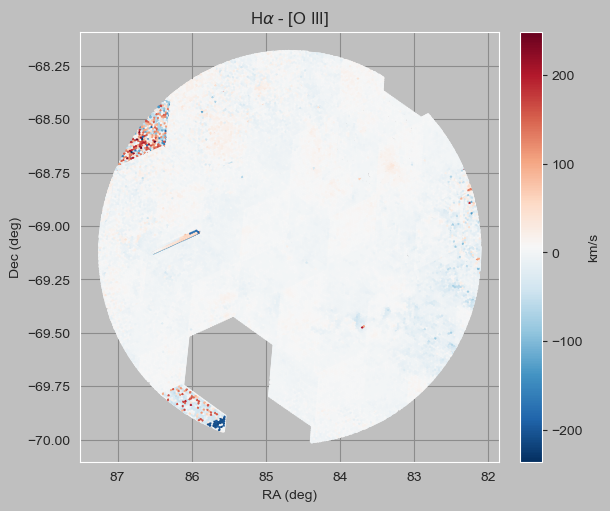

In [57]:
with sns.axes_style(
    "darkgrid",
    rc={
        "axes.facecolor": "0.75",
        "figure.facecolor": "0.75",
        "grid.color": "0.55",
    }
):
    fig, ax = plt.subplots(figsize=(6,5), constrained_layout=True)
    dif_vel1 = ax.scatter(line_rad['RAdeg'], line_rad['DEdeg'],
                             s=1.0, 
                             c=line_rad['V_mean']-line_rad_O['V_mean'], 
                             cmap='RdBu_r')
    ax.invert_xaxis()
    ax.set_xlabel("RA (deg)")
    ax.set_ylabel("Dec (deg)")
    ax.set_title(r'H$\alpha$ - [O III]')
    fig.colorbar(dif_vel1, ax=ax, label='km/s')
    plt.show()

Text(0.5, 1.0, 'H$\\alpha$ - [O III]')

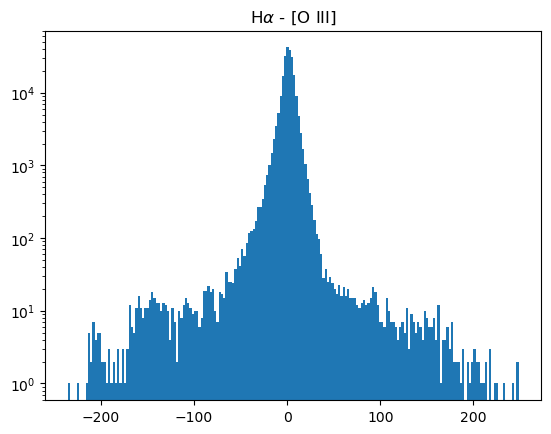

In [53]:
fig, ax = plt.subplots()
plt.hist(line_rad['V_mean']-line_rad_O['V_mean'] , bins=200)
ax.set_yscale("log")


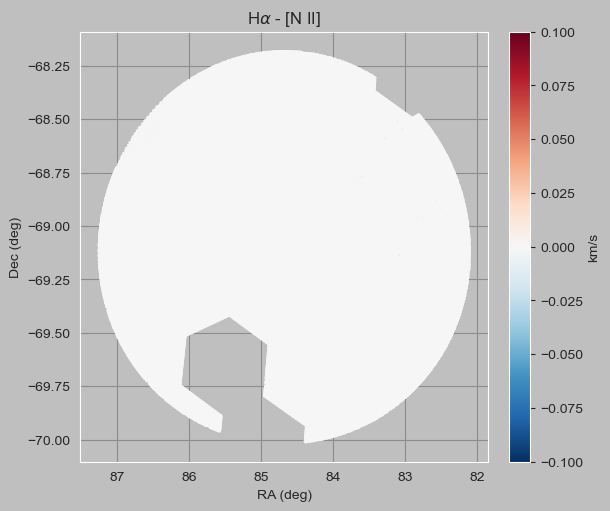

In [58]:
with sns.axes_style(
    "darkgrid",
    rc={
        "axes.facecolor": "0.75",
        "figure.facecolor": "0.75",
        "grid.color": "0.55",
    }
):
    fig, ax = plt.subplots(figsize=(6,5), constrained_layout=True)
    dif_vel1 = ax.scatter(line_rad['RAdeg'], line_rad['DEdeg'],
                             s=1.0, 
                             c=line_rad['V_mean']-line_rad_N['V_mean'], 
                             cmap='RdBu_r')
    ax.invert_xaxis()
    ax.set_xlabel("RA (deg)")
    ax.set_ylabel("Dec (deg)")
    ax.set_title(r'H$\alpha$ - [N II]')
    fig.colorbar(dif_vel1, ax=ax, label='km/s')
    plt.show()

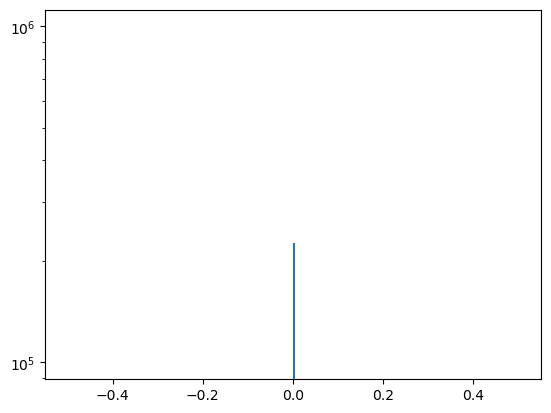

In [46]:
fig, ax = plt.subplots()
plt.hist(line_rad['V_mean']-line_rad_N['V_mean'] , bins=200)
ax.set_yscale("log")

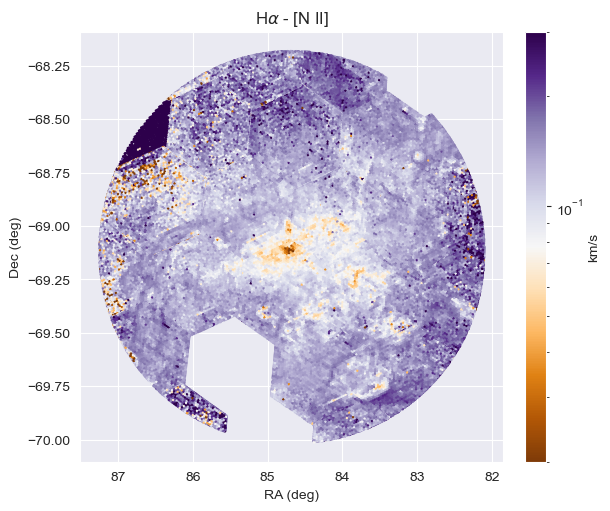

In [54]:
with sns.axes_style("darkgrid"):
    fig, ax = plt.subplots(figsize=(6,5), constrained_layout=True)
    dif_vel1 = ax.scatter(line_rad['RAdeg'], line_rad['DEdeg'],
                             s=1.0, 
                             c=line_rad_N['log_F']/line_rad['log_F'], 
                             cmap='PuOr',
                             vmin=2e-2,
                             vmax=0.3,
                              norm="log",
                         )
    ax.invert_xaxis()
    ax.set_xlabel("RA (deg)")
    ax.set_ylabel("Dec (deg)")
    ax.set_title(r'H$\alpha$ - [N II]')
    fig.colorbar(dif_vel1, ax=ax, label='km/s')
    plt.show()